In [1]:
# standard imports
import pandas as pd
import numpy as np
import sys

sys.path.append("..")

**Data preparation**

In [2]:
from models.prepare import prepare_df

safe_to_drop = ["author_qid", "goodreads_id", "title", "authorLabel"]
shortlists = pd.read_csv("../data/train_novels.csv").drop(columns=safe_to_drop)
test_novels = pd.read_csv("../data/test_novels.csv").drop(columns=safe_to_drop)

df_train = prepare_df(shortlists)
X_train = df_train.copy()
y_train = X_train.pop("n_win")

df_test = prepare_df(test_novels)
X_test = df_test.copy()
y_test = X_test.pop("n_win")


In [4]:
from sklearn.model_selection import cross_validate, GroupKFold
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator
from sklearn.metrics import root_mean_squared_error, r2_score
from models.transformers import RowCountEncoder, impute_topicality, cohort_zscore


def build_pipeline(estimator_name: str, estimator: BaseEstimator) -> Pipeline:
    return Pipeline(
        [
            ("impute_topicality", FunctionTransformer(impute_topicality)),
            (
                "encode_author_data",
                RowCountEncoder(["gender", "birth_country"], "work_qid"),
            ),
            (
                "zscore",
                FunctionTransformer(
                    cohort_zscore,
                    kw_args={"columns": ["awards_as_of_year", "topicality"]},
                ),
            ),
            (
                "drop",
                FunctionTransformer(lambda df: df.drop(columns=["work_qid", "month"])),
            ),
            ("imputer", SimpleImputer(strategy="median")),
            (
                estimator_name,
                estimator,
            ),
        ]
    ).set_output(transform="pandas")


**Model 1: Linear regression**

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn import config_context

#setting up our model and cross-validation RMSE scores
linear_pipeline = build_pipeline("linear", LinearRegression(fit_intercept=False))


with config_context(enable_metadata_routing=True):
    linear_pipeline.fit(X_train, y_train)

y_pred_linear = linear_pipeline.predict(X_test)
r2_linear = r2_score(y_test, y_pred_linear)
rmse_linear = root_mean_squared_error(y_test, y_pred_linear)


Step 2: Plotting our results

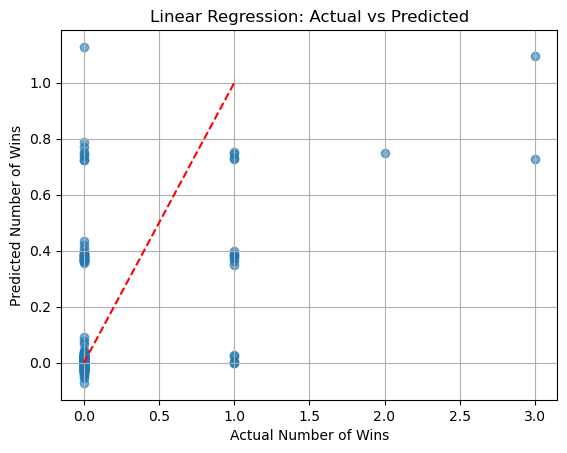

In [7]:
import matplotlib.pyplot as plt

plt.scatter (y_test, y_pred_linear, alpha=0.6)
plt.xlabel("Actual Number of Wins")
plt.ylabel("Predicted Number of Wins")
plt.title("Linear Regression: Actual vs Predicted")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.grid()
plt.show()

**Model 2: Ridge Regression**

In [8]:
#computing optimal alpha via cross-validation
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-4, 4, 50)  

ridge_pipeline = build_pipeline("ridge", RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=GroupKFold(n_splits=5)))


with config_context(enable_metadata_routing=True):
    ridge_pipeline.fit(X_train, y_train, groups=X_train["year"])

y_pred_ridge = ridge_pipeline.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)

Step 2: Plotting our results

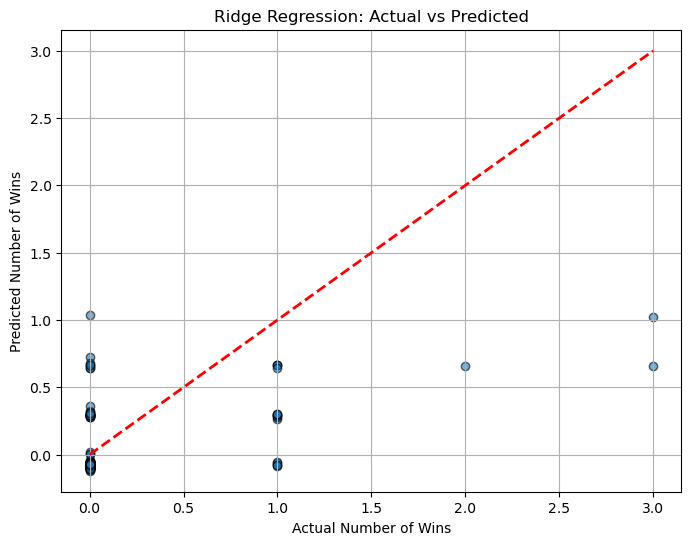

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Number of Wins")
plt.ylabel("Predicted Number of Wins")
plt.title("Ridge Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

Model 3: Lasso Regression

In [11]:
#computing optimal alpha via cross-validation

from sklearn.linear_model import LassoCV

alphas = np.logspace(-4, 4, 50)  

lasso_pipeline = build_pipeline("lasso", LassoCV(alphas=alphas, cv=GroupKFold(n_splits=5), random_state=42, max_iter=10000, fit_intercept=False))

with config_context(enable_metadata_routing=True):
    lasso_pipeline.fit(X_train, y_train, groups=X_train["year"])

y_pred_lasso = lasso_pipeline.predict(X_test)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = root_mean_squared_error(y_test, y_pred_lasso)

Step 2: Plotting our results

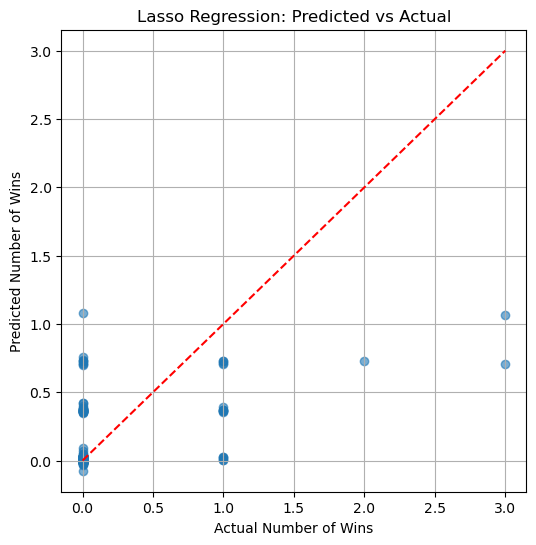

In [12]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lasso, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  

plt.xlabel("Actual Number of Wins")
plt.ylabel("Predicted Number of Wins")
plt.title("Lasso Regression: Predicted vs Actual")
plt.grid(True)
plt.show()


**Model 4: Naive model**

Step 1: Running our model and computing RMSE and R^2 score

In [13]:
from models.naive import naive_win_counts
from sklearn.metrics import r2_score, root_mean_squared_error

n_baseline = 1000

rmse_naive = np.zeros(n_baseline)
r2_naive = np.zeros(n_baseline)

for i in range(n_baseline):
    naive_wins = naive_win_counts(df_test)
    rmse_naive[i] = root_mean_squared_error(y_test, naive_wins)
    r2_naive[i] = r2_score(y_test, naive_wins)

print(f"Naive model RMSE: {rmse_naive.mean():.4f}")
print(f"Naive model R² score: {r2_naive.mean():.4f}")
print(f"Naive model RMSE std: {rmse_naive.std():.4f}")
print(f"Naive model R² std: {r2_naive.std():.4f}")

Naive model RMSE: 0.5499
Naive model R² score: -0.6696
Naive model RMSE std: 0.0219
Naive model R² std: 0.1317


**Comparing models**

In [14]:
performance = pd.DataFrame({
    "Model": ["Naive", "Linear", "Ridge", "Lasso"],
    "R2": [r2_naive.mean(), r2_linear, r2_ridge, r2_lasso],
    "RMSE": [rmse_naive.mean(), rmse_linear, rmse_ridge, rmse_lasso],
    "R2_std": [r2_naive.std(), None, None, None],
    "RMSE_std": [rmse_naive.std(), None, None, None],
})


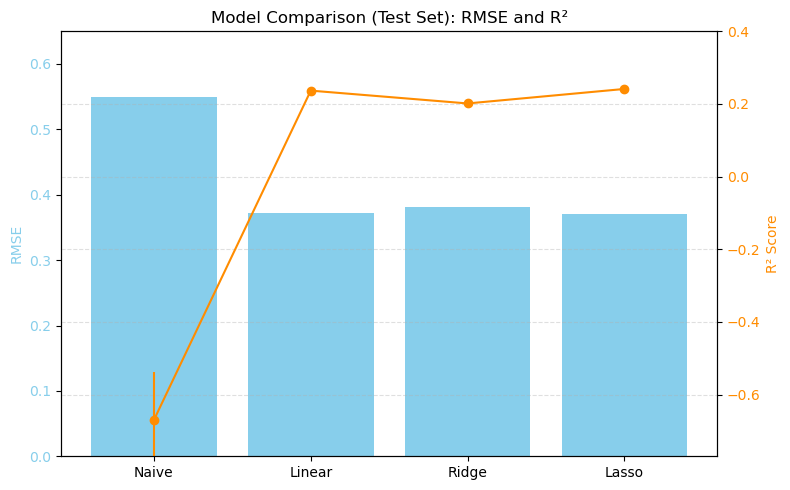

In [16]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# bar plot for RMSE
ax1.bar(performance["Model"], performance["RMSE"], color="skyblue", label="RMSE")
ax1.set_ylabel("RMSE", color="skyblue")
ax1.tick_params(axis='y', labelcolor="skyblue")
ax1.set_ylim(0, max(performance["RMSE"]) + 0.1)

# create a second y-axis for R²
ax2 = ax1.twinx()
ax2.errorbar(performance["Model"], performance["R2"], color="darkorange", marker="o", label="R²", yerr=performance["R2_std"])
ax2.set_ylabel("R² Score", color="darkorange")
ax2.tick_params(axis='y', labelcolor="darkorange")
ax2.set_ylim(min(performance["R2"]) - 0.1, 0.4)

plt.title("Model Comparison (Test Set): RMSE and R²")
fig.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.show()
